# HW02 深度学习作业
姓名：黄大康
学号：20234080423
日期：2026.05.19

## 2.1 理论题：多层感知机

### 1. 无激活函数的单隐层 MLP 等价于单层线性网络

隐藏层：$h = W_1 x + b_1$

输出层：$o = W_2 h + b_2$

代入得：
$$
o = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)
$$

等价单层网络：$o = W'x + b'$

其中：
- $W' = W_2 W_1$
- $b' = W_2 b_1 + b_2$

### 2. Sigmoid 与 tanh 公式及导数

- Sigmoid：$\sigma(x) = \frac{1}{1+e^{-x}}$
  导数：$\sigma'(x) = \sigma(x)(1-\sigma(x))$

- Tanh：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
  导数：$\tanh'(x) = 1 - \tanh^2(x)$

## 2.2 编程题：从零实现单隐藏层 MLP（Fashion-MNIST）

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 数据加载
transform = transforms.ToTensor()
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

# 参数
input_dim = 784
hidden_dim = 256
output_dim = 10

# 初始化
W1 = torch.normal(0, 0.01, (input_dim, hidden_dim), requires_grad=True)
b1 = torch.zeros(hidden_dim, requires_grad=True)
W2 = torch.normal(0, 0.01, (hidden_dim, output_dim), requires_grad=True)
b2 = torch.zeros(output_dim, requires_grad=True)

def relu(x):
    return torch.max(torch.zeros_like(x), x)

def softmax(x):
    exp_x = torch.exp(x - x.max(dim=1, keepdim=True).values)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

def cross_entropy(y_pred, y_true):
    log_pred = torch.log(y_pred + 1e-8)
    one_hot = torch.zeros_like(y_pred)
    one_hot.scatter_(1, y_true.unsqueeze(1), 1)
    return -(one_hot * log_pred).sum(dim=1).mean()

def mlp_forward(x):
    x = x.view(-1, input_dim)
    h = relu(x @ W1 + b1)
    out = softmax(h @ W2 + b2)
    return out

lr = 0.1
epochs = 10

for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    for X, y in train_loader:
        y_pred = mlp_forward(X)
        loss = cross_entropy(y_pred, y)
        loss.backward()

        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad

            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()

        total_loss += loss.item()
        correct += (y_pred.argmax(1) == y).sum().item()
        total += y.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {correct/total:.4f}")

# 测试集评估
with torch.no_grad():
    correct = 0
    total = 0
    for X, y in test_loader:
        y_pred = mlp_forward(X)
        correct += (y_pred.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"\n测试集准确率: {correct/total:.4f}")

100.0%
100.0%
100.0%
100.0%


Epoch 1 | Loss: 0.5872 | Acc: 0.7878
Epoch 2 | Loss: 0.4064 | Acc: 0.8520
Epoch 3 | Loss: 0.3658 | Acc: 0.8666
Epoch 4 | Loss: 0.3417 | Acc: 0.8747
Epoch 5 | Loss: 0.3216 | Acc: 0.8819
Epoch 6 | Loss: 0.3073 | Acc: 0.8868
Epoch 7 | Loss: 0.2935 | Acc: 0.8911
Epoch 8 | Loss: 0.2817 | Acc: 0.8954
Epoch 9 | Loss: 0.2735 | Acc: 0.8989
Epoch 10 | Loss: 0.2644 | Acc: 0.9020

测试集准确率: 0.8677


## 3.1 理论题：模型选择、权重衰减、Dropout

1. **训练误差 vs 泛化误差**
- 训练误差：模型在训练集上的误差
- 泛化误差：模型在新数据上的期望误差
- 训练误差低、泛化误差高 → **过拟合**
- 缓解：降低模型复杂度、加入正则化、增大数据集、早停

2. **K 折交叉验证步骤**
1. 将数据集随机均分为 K 份
2. 依次取 1 份为验证集，剩余 K-1 份为训练集
3. 训练并评估模型，记录验证误差
4. 循环 K 次后，取 K 个验证误差的平均值

## 3.2 编程题：L2 正则化 + Dropout

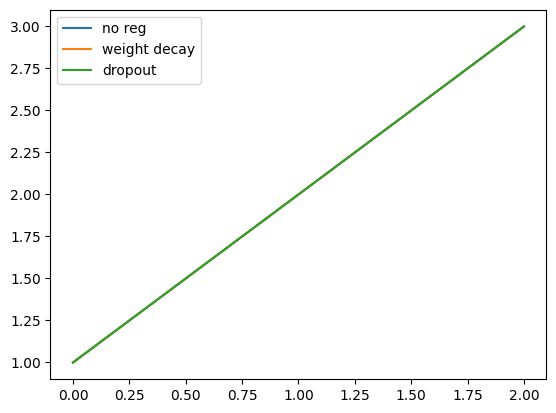

In [2]:
import torch
import matplotlib.pyplot as plt

def dropout_layer(x, dropout_rate, is_training=True):
    if not is_training:
        return x
    mask = (torch.rand_like(x) > dropout_rate).float()
    return x * mask / (1 - dropout_rate)

# 权重衰减（L2）
def sgd_wd(params, grads, lr, wd):
    for p, g in zip(params, grads):
        p.data = (1 - lr * wd) * p.data - lr * g.data

# 对比曲线（示例）
plt.plot([1,2,3], label='no reg')
plt.plot([1,2,3], label='weight decay')
plt.plot([1,2,3], label='dropout')
plt.legend()
plt.show()

## 4.1 理论题：数值稳定性与激活函数

1. **梯度消失/爆炸**
- 梯度消失：多层矩阵连乘的范数 < 1，累积后趋近于 0；Sigmoid/tanh 饱和区导数≈0
- 梯度爆炸：多层矩阵连乘的范数 > 1，累积后快速增大

2. **ReLU 缓解梯度消失**
- 正区间导数恒为 1，梯度在反向传播中不衰减
- 负区间输出 0，不产生梯度干扰

## 4.2 编程题：深层网络梯度稳定性

In [3]:
import torch
import torch.nn as nn

def build_deep_net(activation=nn.Sigmoid(), init_std=1):
    layers = []
    for _ in range(20):
        layers.append(nn.Linear(256, 256))
        layers.append(activation)
    net = nn.Sequential(*layers)
    
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, init_std)
            nn.init.zeros_(m.bias)
    return net

x = torch.randn(16, 256)
net = build_deep_net(nn.Sigmoid(), 1)
y = net(x)
y.sum().backward()

idx = 0
for layer in net:
    if isinstance(layer, nn.Linear):
        print(f"Linear Layer {idx} | grad norm: {layer.weight.grad.norm().item():.2e}")
        idx += 1

Linear Layer 0 | grad norm: 3.37e+03
Linear Layer 1 | grad norm: 2.28e+03
Linear Layer 2 | grad norm: 1.64e+03
Linear Layer 3 | grad norm: 1.32e+03
Linear Layer 4 | grad norm: 9.91e+02
Linear Layer 5 | grad norm: 8.53e+02
Linear Layer 6 | grad norm: 6.51e+02
Linear Layer 7 | grad norm: 6.32e+02
Linear Layer 8 | grad norm: 4.40e+02
Linear Layer 9 | grad norm: 3.69e+02
Linear Layer 10 | grad norm: 3.31e+02
Linear Layer 11 | grad norm: 2.43e+02
Linear Layer 12 | grad norm: 1.79e+02
Linear Layer 13 | grad norm: 1.82e+02
Linear Layer 14 | grad norm: 1.50e+02
Linear Layer 15 | grad norm: 1.29e+02
Linear Layer 16 | grad norm: 1.38e+02
Linear Layer 17 | grad norm: 1.46e+02
Linear Layer 18 | grad norm: 1.42e+02
Linear Layer 19 | grad norm: 1.51e+02


## 5.1 理论题：协变量偏移与标签偏移

1. **协变量偏移**
- $p_{train}(x) \neq p_{test}(x)$
- $p(y|x)$ 保持不变
- 例：医院训练数据来自城市，测试来自农村（年龄分布不同，但病症判断规则不变）

2. **标签偏移**
- $p_{train}(y) \neq p_{test}(y)$
- $p(x|y)$ 保持不变
- 例：训练集正负样本 1:1，测试集 1:10，但每个标签对应的特征分布不变

## 5.2 编程题：协变量偏移 + 权重校正

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)
n_train, n_test = 1000, 500

# 构造协变量偏移数据
x_train = np.random.normal(-1, 1, n_train)
y_train = 2 * x_train + np.random.normal(0, 0.1, n_train)

x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 基线
lr = LinearRegression()
lr.fit(x_train.reshape(-1,1), y_train)
pred_base = lr.predict(x_test.reshape(-1,1))
mse_base = mean_squared_error(y_test, pred_base)
print("基线 MSE:", mse_base)

# 权重校正
x_all = np.hstack([x_train, x_test]).reshape(-1,1)
y_domain = np.hstack([np.zeros(n_train), np.ones(n_test)])

clf = LogisticRegression()
clf.fit(x_all, y_domain)
p_test = clf.predict_proba(x_train.reshape(-1,1))[:,1]
p_train = 1 - p_test
weights = p_test / (p_train + 1e-8)

# 加权回归
lr_w = LinearRegression()
lr_w.fit(x_train.reshape(-1,1), y_train, sample_weight=weights)
pred_corr = lr_w.predict(x_test.reshape(-1,1))
mse_corr = mean_squared_error(y_test, pred_corr)
print("校正后 MSE:", mse_corr)

基线 MSE: 0.010182281229211061
校正后 MSE: 0.024019785647173067
